# Finetuning
This notebook fine‑tunes a sentiment classifier on the Rotten Tomatoes dataset using three strategies:

**Goal:** Compare three strategies for text classification:
1) Frozen encoder (train head only),
2) Full fine-tuning,
3) Parameter-Efficient Fine-Tuning (LoRA).

We report **Accuracy**, **Macro-F1**, confusion matrices, and parameter counts, and save a CSV summary of results.

### Setup: Install and import Dependencies

We install and import all dependencies, set random seeds for reproducibility, and detect the compute device (CPU/GPU).

In [1]:
!pip install evaluate transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


In [2]:
import os, math, random, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
import evaluate

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, Trainer, TrainingArguments,
                          set_seed)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.extmath import softmax

from peft import LoraConfig, get_peft_model, TaskType

### Reproducibility
 Fixes random seeds and controls nondeterminism where possible.

In [7]:
SEED = 2
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Device:{DEVICE}')


Device:cuda


### Load Dataset
 Downloads the Rotten Tomatoes dataset and previews a few rows.
 The dataset consists of movie reviews and their labels corresponding to if they are positive or negative

In [8]:
ds = load_dataset("rotten_tomatoes")
print(ds)

print("\nExample rows:")

#Filter the training set for examples with label 0 and 1
label_0_examples = ds["train"].filter(lambda example: example["label"] == 0)
label_1_examples = ds["train"].filter(lambda example: example["label"] == 1)

# Print random example with label 0 and 1
n = np.random.randint(0, len(label_0_examples))
print("\nExample row with label 0:")
print(label_0_examples[n])
print("\nExample row with label 1:")
print(label_1_examples[n])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})

Example rows:

Example row with label 0:
{'text': "it's exactly what you'd expect .", 'label': 0}

Example row with label 1:
{'text': "while guzmán frustratingly refuses to give pinochet's crimes a political context , his distance from the material is mostly admirable .", 'label': 1}


In [9]:
train_ds = ds["train"]
valid_ds = ds['validation']
test_ds = ds["test"]

print(f"Sizes: train={len(train_ds)}, valid={len(valid_ds)}, test={len(test_ds)}")

Sizes: train=8530, valid=1066, test=1066


The distribution of label is nearly 50:50

In [10]:
def label_counts(d):
    counts = {0:0, 1:0}
    for ex in d:
        counts[ex["label"]] += 1
    return counts

for split_name, split_ds in [("train", train_ds), ("valid", valid_ds), ("test", test_ds)]:
    counts = label_counts(split_ds)
    print(f"{split_name}: neg={counts[0]} | pos={counts[1]}")

train: neg=4265 | pos=4265
valid: neg=533 | pos=533
test: neg=533 | pos=533


### Tokenization

 Tokenizes text with the selected pretrained tokenizer and explores sequence lengths.

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/8530 [00:00<?, ? examples/s]

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

Column([1, 1, 1, 1, 1])
Column([[101, 8295, 2135, 16164, 1999, 1996, 5450, 1997, 1037, 3585, 2338, 22057, 2000, 2166, 1010, 6990, 2210, 1016, 9020, 23210, 4321, 2302, 6293, 9961, 1012, 102], [101, 10862, 12266, 1998, 23873, 3993, 1012, 102], [101, 2009, 1005, 1055, 2066, 1037, 1000, 2502, 10720, 1000, 10301, 1997, 1996, 8670, 9648, 2099, 1011, 24182, 14586, 6080, 1010, 2069, 2122, 4364, 2024, 2062, 19741, 26418, 15608, 2084, 2576, 10134, 1012, 102], [101, 1996, 2466, 3957, 20851, 4495, 2005, 2312, 1011, 4094, 2895, 1998, 23873, 1010, 2029, 2472, 2016, 22510, 10556, 5311, 6067, 2007, 14388, 8066, 1012, 102], [101, 2417, 5202, 1000, 2196, 7659, 8413, 1012, 102]])
Column([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1]])


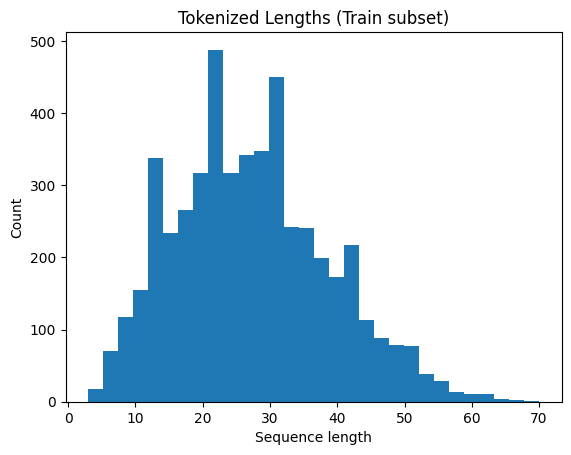

In [11]:
MAX_LEN = 128
MODEL_NAME = "distilbert-base-uncased"


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def tokenize_function(batch):
    return tokenizer(batch["text"], padding=False, truncation=True, max_length=MAX_LEN) # we will pad on-the-fly thats why no padding here

tokenized_train = train_ds.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_valid = valid_ds.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_test  = test_ds.map(tokenize_function,  batched=True, remove_columns=["text"])


print(tokenized_test['label'])
print(tokenized_test['input_ids'])
print(tokenized_test['attention_mask'])

# Length histogram
lengths = [len(x) for x in tokenized_train["input_ids"][:5000]]
plt.figure()
plt.hist(lengths, bins=30)
plt.title("Tokenized Lengths (Train subset)")
plt.xlabel("Sequence length")
plt.ylabel("Count")
plt.show()


We can see that max sequence length is about 70 so using 128 as max_len makes sense

We now use DataCollatorWithPadding to dynamically pad the sequences in the batch so that padding is according to longest sequence in the current batch. This makes it a bit faster

In [12]:
# Data collator (dynamic padding)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)    #dynamic padding ensures padding is done according to longest sequence in the current batch rather than global longest sequence
print(data_collator)

DataCollatorWithPadding(tokenizer=DistilBertTokenizerFast(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
), padding=True, max_length=None, pad_to_multiple_of=None, return_tensors='pt')


### Metrics
 Sets up accuracy/F1 and helper utilities (confusion matrix, reports). This way we can see how different models perform with different method of fine-tuning

In [13]:
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

#Given teh predictions this function will calculate the accuracy and f1-score
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy.compute(predictions=preds, references=labels)["accuracy"]
    f1_macro = f1.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1": f1_macro}

#This function takes in the trainer and the test dataset, does the inference and calculates metrics on predicted data
def predict_and_eval(trainer, eval_ds, split_name="eval"):
    preds = trainer.predict(eval_ds)
    metrics = {
        "accuracy": float(accuracy.compute(predictions=np.argmax(preds.predictions, axis=-1), references=preds.label_ids)["accuracy"]),
        "f1": float(f1.compute(predictions=np.argmax(preds.predictions, axis=-1), references=preds.label_ids, average="macro")["f1"]),
    }
    return preds, metrics

#TO plot confusion matrix for model performance
def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg","pos"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()


#This function will be helpful to see how many paramters are being used for fine-tuning
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def pretty_param_counts(model, label="Model"):
    total, trainable = count_parameters(model)
    print(f"{label}: total params = {total:,} | trainable = {trainable:,} | trainable% = {100*trainable/total:.2f}%")
    return {"total": int(total), "trainable": int(trainable), "ratio": float(trainable/total)}


# Model Initialization
We setup multiple methods to initialize the model, finetuning and reporting of results

In [14]:
id2label = {0: "neg", 1: "pos"}
label2id = {v: k for k, v in id2label.items()}

BATCH_SIZE = 16

# initializes the model with a classification head
def make_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, id2label=id2label, label2id=label2id
    )
    return model

#This will set up the training arguments and initialize the trainer with those arguments
def train_setup(model, out_dir, lr, epochs, run_name):
    args = TrainingArguments(
        output_dir=out_dir,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=epochs,
        learning_rate=lr,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        report_to=[],
        seed=SEED,
        fp16=torch.cuda.is_available(),
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_valid,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    return trainer

#Starts fine-tuning and reports the performance on test and validation set
def run_and_report(trainer, label):

    trainer.train()
    val_metrics = trainer.evaluate()
    test_preds, test_metrics = predict_and_eval(trainer, tokenized_test, split_name="test")

    print(f"\n[{label}] Validation metrics:", val_metrics)
    print(f"[{label}] Test metrics:", test_metrics)

    return val_metrics, test_preds, test_metrics

def logits_to_probs(logits):
    return softmax(logits)



## Baseline Model Performance
Before doing any fine-tuning, we would like to see the performance of base model without any fine-tuning

In [16]:
baseline_model = make_model()

baseline_trainer = train_setup(
    baseline_model,
    out_dir="outputs_distilbert_rotten/baseline",
    lr=1e-5,
    epochs=1,
    run_name="baseline"
)

baseline_counts = pretty_param_counts(baseline_model, "Baseline")

baseline_val_metrics = baseline_trainer.evaluate()
baseline_test_preds, baseline_test_metrics = predict_and_eval(baseline_trainer, tokenized_test, split_name="test")

print(f"\n[Baseline] Validation metrics:", baseline_val_metrics)
print(f"[Baseline] Test metrics:", baseline_test_metrics)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Baseline: total params = 66,955,010 | trainable = 66,955,010 | trainable% = 100.00%


/tmp/ipython-input-1699663147.py:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



[Baseline] Validation metrics: {'eval_loss': 0.692835807800293, 'eval_model_preparation_time': 0.0024, 'eval_accuracy': 0.50093808630394, 'eval_f1': 0.33541458658529155, 'eval_runtime': 0.9844, 'eval_samples_per_second': 1082.871, 'eval_steps_per_second': 68.06}
[Baseline] Test metrics: {'accuracy': 0.50093808630394, 'f1': 0.33541458658529155}


## Frozen Encoder

 Only trains the classification head while freezing the encoder.

In [18]:
OUTPUT_DIR = "outputs_distilbert_rotten"
LR_HEAD = 1e-3
EPOCHS_HEAD = 3

frozen_model = make_model()

#Freeze the encoder (DistilBERT backbone) — train only the classifier head
for p in frozen_model.distilbert.parameters():
    p.requires_grad = False

print('='*50)
print("Trainable parameter report (Frozen Baseline):")
frozen_counts = pretty_param_counts(frozen_model, "Frozen-Encoder")

frozen_trainer = train_setup(
    frozen_model,
    out_dir=os.path.join(OUTPUT_DIR, "frozen_head"),
    lr=LR_HEAD,
    epochs=EPOCHS_HEAD,
    run_name="frozen_head"
)

frozen_val_metrics, frozen_test_preds, frozen_test_metrics = run_and_report(frozen_trainer, "Frozen-Encoder")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1699663147.py:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Trainable parameter report (Frozen Baseline):
Frozen-Encoder: total params = 66,955,010 | trainable = 592,130 | trainable% = 0.88%


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.511000,0.434405,0.792683,0.789977
2,0.477800,0.408704,0.818949,0.818945
3,0.419500,0.398748,0.815197,0.815170



[Frozen-Encoder] Validation metrics: {'eval_loss': 0.40870407223701477, 'eval_accuracy': 0.8189493433395872, 'eval_f1': 0.8189453601107424, 'eval_runtime': 0.7302, 'eval_samples_per_second': 1459.821, 'eval_steps_per_second': 91.752, 'epoch': 3.0}
[Frozen-Encoder] Test metrics: {'accuracy': 0.7823639774859287, 'f1': 0.7823264328967752}


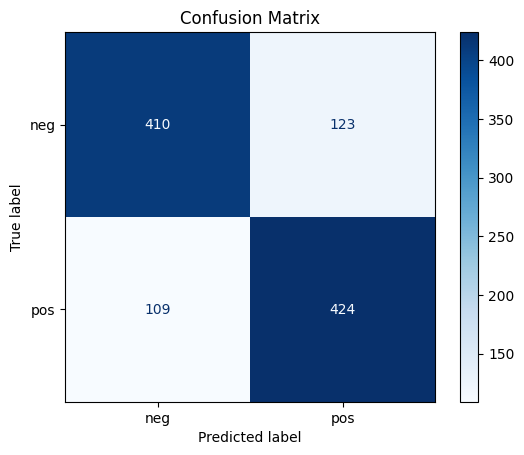

In [19]:
# Confusion matrix on test
frozen_y_true = frozen_test_preds.label_ids
frozen_y_pred = np.argmax(frozen_test_preds.predictions, axis=-1)
plot_confusion(frozen_y_true, frozen_y_pred, title="Frozen-Encoder Confusion Matrix")

# Save artifacts
frozen_trainer.save_model(os.path.join(OUTPUT_DIR, "frozen_head", "best_model"))
with open(os.path.join(OUTPUT_DIR, "frozen_head", "test_metrics.json"), "w") as f:
    json.dump(frozen_test_metrics, f, indent=2)

## Full Fine‑Tuning

Unfreezes the entire model and fine‑tunes end‑to‑end.

In [20]:
EPOCHS_FULL = 3        # Full fine-tune
LR_FULL = 2e-5

full_model = make_model()

print("Trainable parameter report (Full Fine-Tune):")
full_counts = pretty_param_counts(full_model, "Full-FT")

full_trainer = train_setup(
    full_model,
    out_dir=os.path.join(OUTPUT_DIR, "full_ft"),
    lr=LR_FULL,
    epochs=EPOCHS_FULL,
    run_name="full_ft"
)

full_val_metrics, full_test_preds, full_test_metrics = run_and_report(full_trainer, "Full-FT")




Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1699663147.py:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Trainable parameter report (Full Fine-Tune):
Full-FT: total params = 66,955,010 | trainable = 66,955,010 | trainable% = 100.00%


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.405400,0.375689,0.838649,0.838203
2,0.268400,0.410631,0.844278,0.844211
3,0.131300,0.502598,0.848968,0.848967



[Full-FT] Validation metrics: {'eval_loss': 0.5025981664657593, 'eval_accuracy': 0.848968105065666, 'eval_f1': 0.8489669088755459, 'eval_runtime': 0.7068, 'eval_samples_per_second': 1508.184, 'eval_steps_per_second': 94.792, 'epoch': 3.0}
[Full-FT] Test metrics: {'accuracy': 0.8470919324577861, 'f1': 0.8470853387332824}


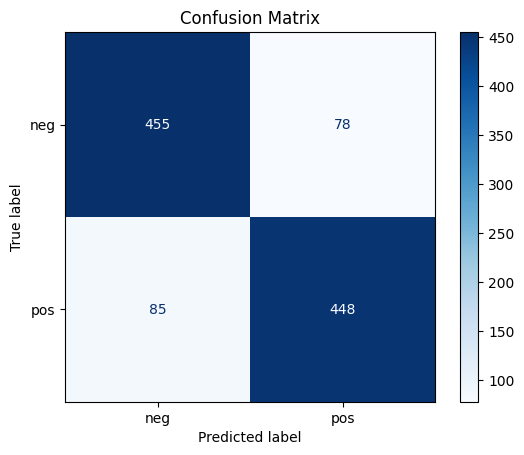

In [21]:
# Confusion matrix on test
full_y_true = full_test_preds.label_ids
full_y_pred = np.argmax(full_test_preds.predictions, axis=-1)
plot_confusion(full_y_true, full_y_pred, title="Full-FT Confusion Matrix")

# Save artifacts
full_trainer.save_model(os.path.join(OUTPUT_DIR, "full_ft", "best_model"))
with open(os.path.join(OUTPUT_DIR, "full_ft", "test_metrics.json"), "w") as f:
    json.dump(full_test_metrics, f, indent=2)

## Parameter-Efficient Fine-Tuning (LoRA)
We apply LoRA adapters to attention projections (e.g., `q_lin`, `v_lin`) in DistilBERT.
LoRA trains a small number of extra parameters while keeping the base model weights (mostly) frozen.
We report trainable parameter fraction and compare to the previous methods

In [22]:
EPOCHS_LORA = 3        # LoRA fine-tune
LR_LORA = 5e-4
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
LORA_TARGETS = ["q_lin", "v_lin"]  # DistilBERT attention proj names



lora_base_model = make_model()

# Apply LoRA to DistilBERT attention projections (q_lin, v_lin)
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGETS,
    bias="none"
)

lora_model = get_peft_model(lora_base_model, lora_config)
print("Trainable parameter report (LoRA):")
lora_counts = pretty_param_counts(lora_model, "LoRA")

lora_trainer = train_setup(
    lora_model,
    out_dir=os.path.join(OUTPUT_DIR, "lora_ft"),
    lr=LR_LORA,
    epochs=EPOCHS_LORA,
    run_name="lora_ft"
)

lora_val_metrics, lora_test_preds, lora_test_metrics = run_and_report(lora_trainer, "LoRA")




Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1699663147.py:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Trainable parameter report (LoRA):
LoRA: total params = 67,694,596 | trainable = 739,586 | trainable% = 1.09%


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.406200,0.368478,0.840525,0.840343
2,0.348200,0.353310,0.842402,0.842156
3,0.278300,0.359534,0.844278,0.844277



[LoRA] Validation metrics: {'eval_loss': 0.3595336377620697, 'eval_accuracy': 0.8442776735459663, 'eval_f1': 0.8442771253977641, 'eval_runtime': 0.7584, 'eval_samples_per_second': 1405.611, 'eval_steps_per_second': 88.345, 'epoch': 3.0}
[LoRA] Test metrics: {'accuracy': 0.8367729831144465, 'f1': 0.8367522962264085}


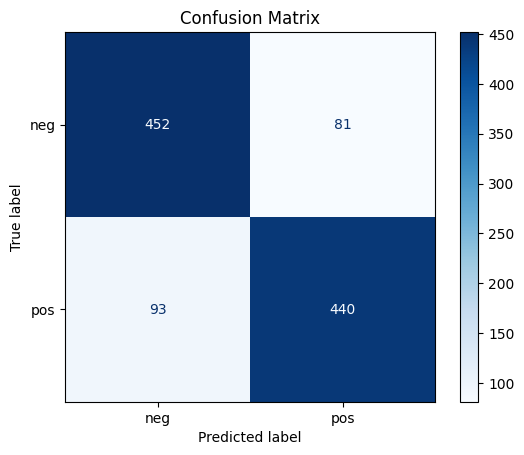

In [23]:
# Confusion matrix on test
lora_y_true = lora_test_preds.label_ids
lora_y_pred = np.argmax(lora_test_preds.predictions, axis=-1)
plot_confusion(lora_y_true, lora_y_pred, title="LoRA Confusion Matrix")

# Save LoRA adapters
lora_trainer.save_model(os.path.join(OUTPUT_DIR, "lora_ft", "best_lora_adapters"))

# (Optional) Merge LoRA weights into the base for deployment
# merged_model = lora_model.merge_and_unload()
# merged_model.save_pretrained(os.path.join(OUTPUT_DIR, "lora_ft", "merged_model"))
with open(os.path.join(OUTPUT_DIR, "lora_ft", "test_metrics.json"), "w") as f:
    json.dump(lora_test_metrics, f, indent=2)

## Summary & Next Steps
We compare methods on test Accuracy/Macro-F1 and the percentage of trainable parameters.
**Next steps:**
- Try different LoRA target modules (`k_lin`, `out_lin`) and ranks.
- Sweep learning rates/epochs.
- Add ROC-AUC and per-class precision/recall to the report.
- Push the best model to the 🤗 Hub or package it for inference.

In [24]:

summary_rows = []

def add_row(method, counts, val_metrics, test_metrics):
    summary_rows.append({
        "Method": method,
        "Trainable Params": counts["trainable"] if isinstance(counts, dict) else counts,
        "Trainable %": round(100*(counts["trainable"]/counts["total"]), 2) if isinstance(counts, dict) else None,
        "Val/Best F1": round(float(val_metrics.get("eval_f1", val_metrics.get("f1", np.nan))), 4),
        "Test Acc": round(float(test_metrics["accuracy"]), 4),
        "Test Macro-F1": round(float(test_metrics["f1"]), 4),
    })

add_row("Baseline", baseline_counts, baseline_val_metrics, baseline_test_metrics )
add_row("Frozen-Encoder", frozen_counts, frozen_val_metrics, frozen_test_metrics)
add_row("Full Fine-Tune", full_counts, full_val_metrics, full_test_metrics)
add_row("LoRA", lora_counts, lora_val_metrics, lora_test_metrics)

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_path = os.path.join(OUTPUT_DIR, "summary.csv")
summary_df.to_csv(summary_path, index=False)
print("Saved summary to:", summary_path)


,Method,Trainable Params,Trainable %,Val/Best F1,Test Acc,Test Macro-F1
0,Baseline,66955010,100.00,0.3354,0.5009,0.3354
1,Frozen-Encoder,592130,0.88,0.8189,0.7824,0.7823
2,Full Fine-Tune,66955010,100.00,0.8490,0.8471,0.8471
3,LoRA,739586,1.09,0.8443,0.8368,0.8368


Saved summary to: outputs_distilbert_rotten/summary.csv


As visible different approaches can be tried for fine-tuning depending on the resources available for the task at hand. In our case, LoRA fine-tuning is a good choice as we get similiar performace to full fine-tuning, while only finetuning 1% of the total parameters, saving cost and time.

## Example Deployment
we can use [gradio](https://www.gradio.app/) library to have user type in their review and our LoRA model predict if it is a positive or negative review

In [27]:
import numpy as np
import torch
import gradio as gr
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel



BASE_MODEL = "distilbert-base-uncased"
ADAPTER_DIR = "/content/outputs_distilbert_rotten/lora_ft/best_lora_adapters"
MAX_LEN = int(globals().get("MAX_LEN", 256))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



tokenizer_used = AutoTokenizer.from_pretrained(BASE_MODEL)
base = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=2)
if not os.path.isdir(ADAPTER_DIR):
    raise FileNotFoundError(
        f"LoRA adapter directory '{ADAPTER_DIR}' not found. "
        f"Either set ADAPTER_DIR correctly or ensure `lora_trainer.model` is available."
    )
model = PeftModel.from_pretrained(base, ADAPTER_DIR)

model.to(DEVICE).eval()

id2label = {0: "negative", 1: "positive"}
label2id = {v: k for k, v in id2label.items()}

def predict_sentiment(text: str):
    text = (text or "").strip()
    if not text:
        return "Please enter a review.", {"negative": 0.0, "positive": 0.0}

    enc = tokenizer_used(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]

    pred_id = int(np.argmax(probs))
    pred_label = id2label[pred_id]
    scores = {"negative": float(probs[0]), "positive": float(probs[1])}
    return f"Prediction: **{pred_label}**", scores

# Example templates to click-and-try
example_reviews = [
    "An absolute joy to watch—funny, heartfelt, and beautifully acted.",
    "What a slog. I kept checking the time waiting for it to end.",
    "It's okay: a few good laughs, but the story never really takes off.",
    "The chemistry between the leads carries an otherwise predictable script.",
    "Technically impressive, emotionally hollow—style over substance.",
    "I wanted to love it, but the pacing is uneven and the dialogue is clunky.",
    "Okish"
]

with gr.Blocks() as demo:
    gr.Markdown("## Sentiment Analysis (LoRA-Tuned DistilBERT)")
    gr.Markdown("Type a movie review or click an example. The model returns a label and class probabilities.")

    inp = gr.Textbox(label="Review", lines=4, placeholder="Type or paste a review here…")
    run_btn = gr.Button("Analyze")

    out_text = gr.Markdown()
    out_scores = gr.Label(num_top_classes=2, label="Class probabilities")

    run_btn.click(fn=predict_sentiment, inputs=inp, outputs=[out_text, out_scores])

    gr.Examples(examples=[[e] for e in example_reviews], inputs=[inp])

# Launch the app (set share=True if you want a public link)
demo.launch(share=False, debug=False)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>